In [57]:
import jax.numpy as jnp
import pickle

In [58]:
# kgd_lengthscales = {
#     "MFLD": {
#         "Scales": None,
#         "KGD_scales": None,
#         "MMD_scales" : None
#     },

#     "Extensible Sampling": {
#         "Scales": None,
#         "KGD_scales": None,
#         "MMD_scales" : None},

#     "Variational Gradient Descent": {
#         "Scales": None,
#         "KGD_scales": None,
#         "MMD_scales" : None
#     }
# }

In [59]:
gamma = 10.0
filename_lengthscales = f"saved_data/kgd_lengthscales_gamma_{gamma}.pkl"

In [60]:
# import pickle

# # Sauvegarde dans un fichier binaire
# with open(filename_lengthscales, "wb") as gg:
#     pickle.dump(kgd_lengthscales, gg)

In [ ]:
import jax.numpy as jnp
import pickle

# load
with open(filename_lengthscales, "rb") as g:
    kgd_lengthscales_loaded = pickle.load(g)

In [62]:
evaluations_grad_L = jnp.arange(0,5000) * 25
eval_gradL_ES = jnp.arange(0,25) * 4050

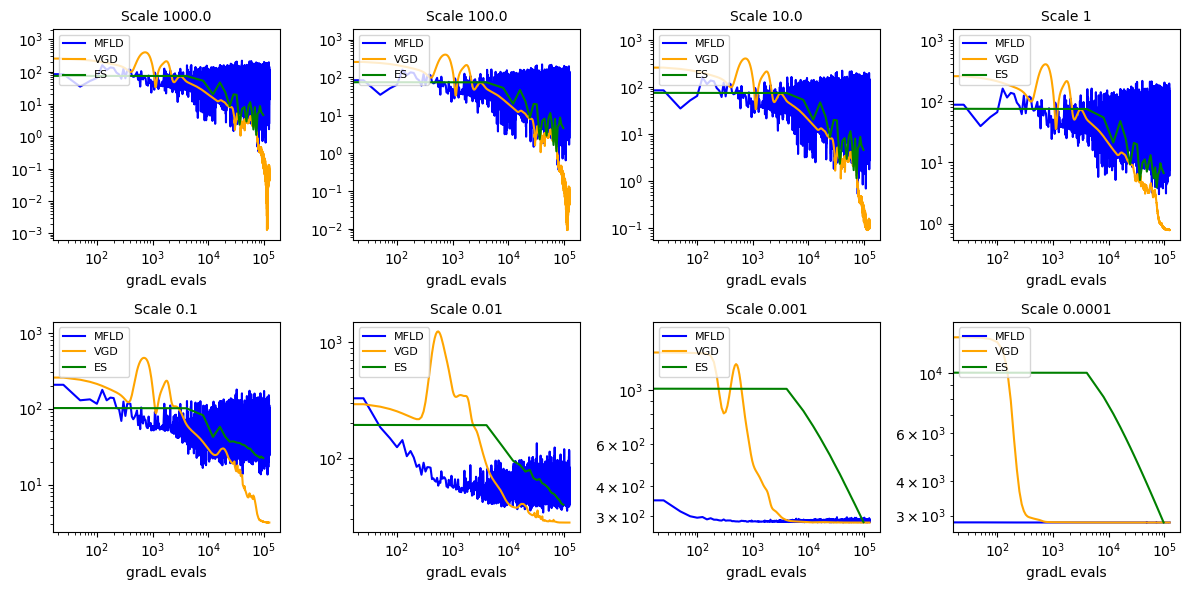

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for s, scales in enumerate(kgd_lengthscales_loaded["MFLD"]["Scales"]):
    i = s // 4
    j = s % 4
    axes[i, j].plot(evaluations_grad_L, kgd_lengthscales_loaded["MFLD"]["KGD_scales"][s], label='MFLD', color='blue')
    axes[i, j].plot(evaluations_grad_L, kgd_lengthscales_loaded["Variational Gradient Descent"]["KGD_scales"][s], label='VGD', color='orange')
    axes[i, j].plot(eval_gradL_ES, kgd_lengthscales_loaded["Extensible Sampling"]["KGD_scales"][s], label='ES', color='green')
    axes[i, j].set_title(f'Scale {scales}', fontsize=10)  # Réduire la taille du titre
    axes[i, j].set_xlabel('gradL evals')
    axes[i, j].set_xscale('log')
    axes[i, j].set_yscale('log')
    axes[i, j].legend(fontsize=8, loc='upper left')  

plt.tight_layout()
plt.show()

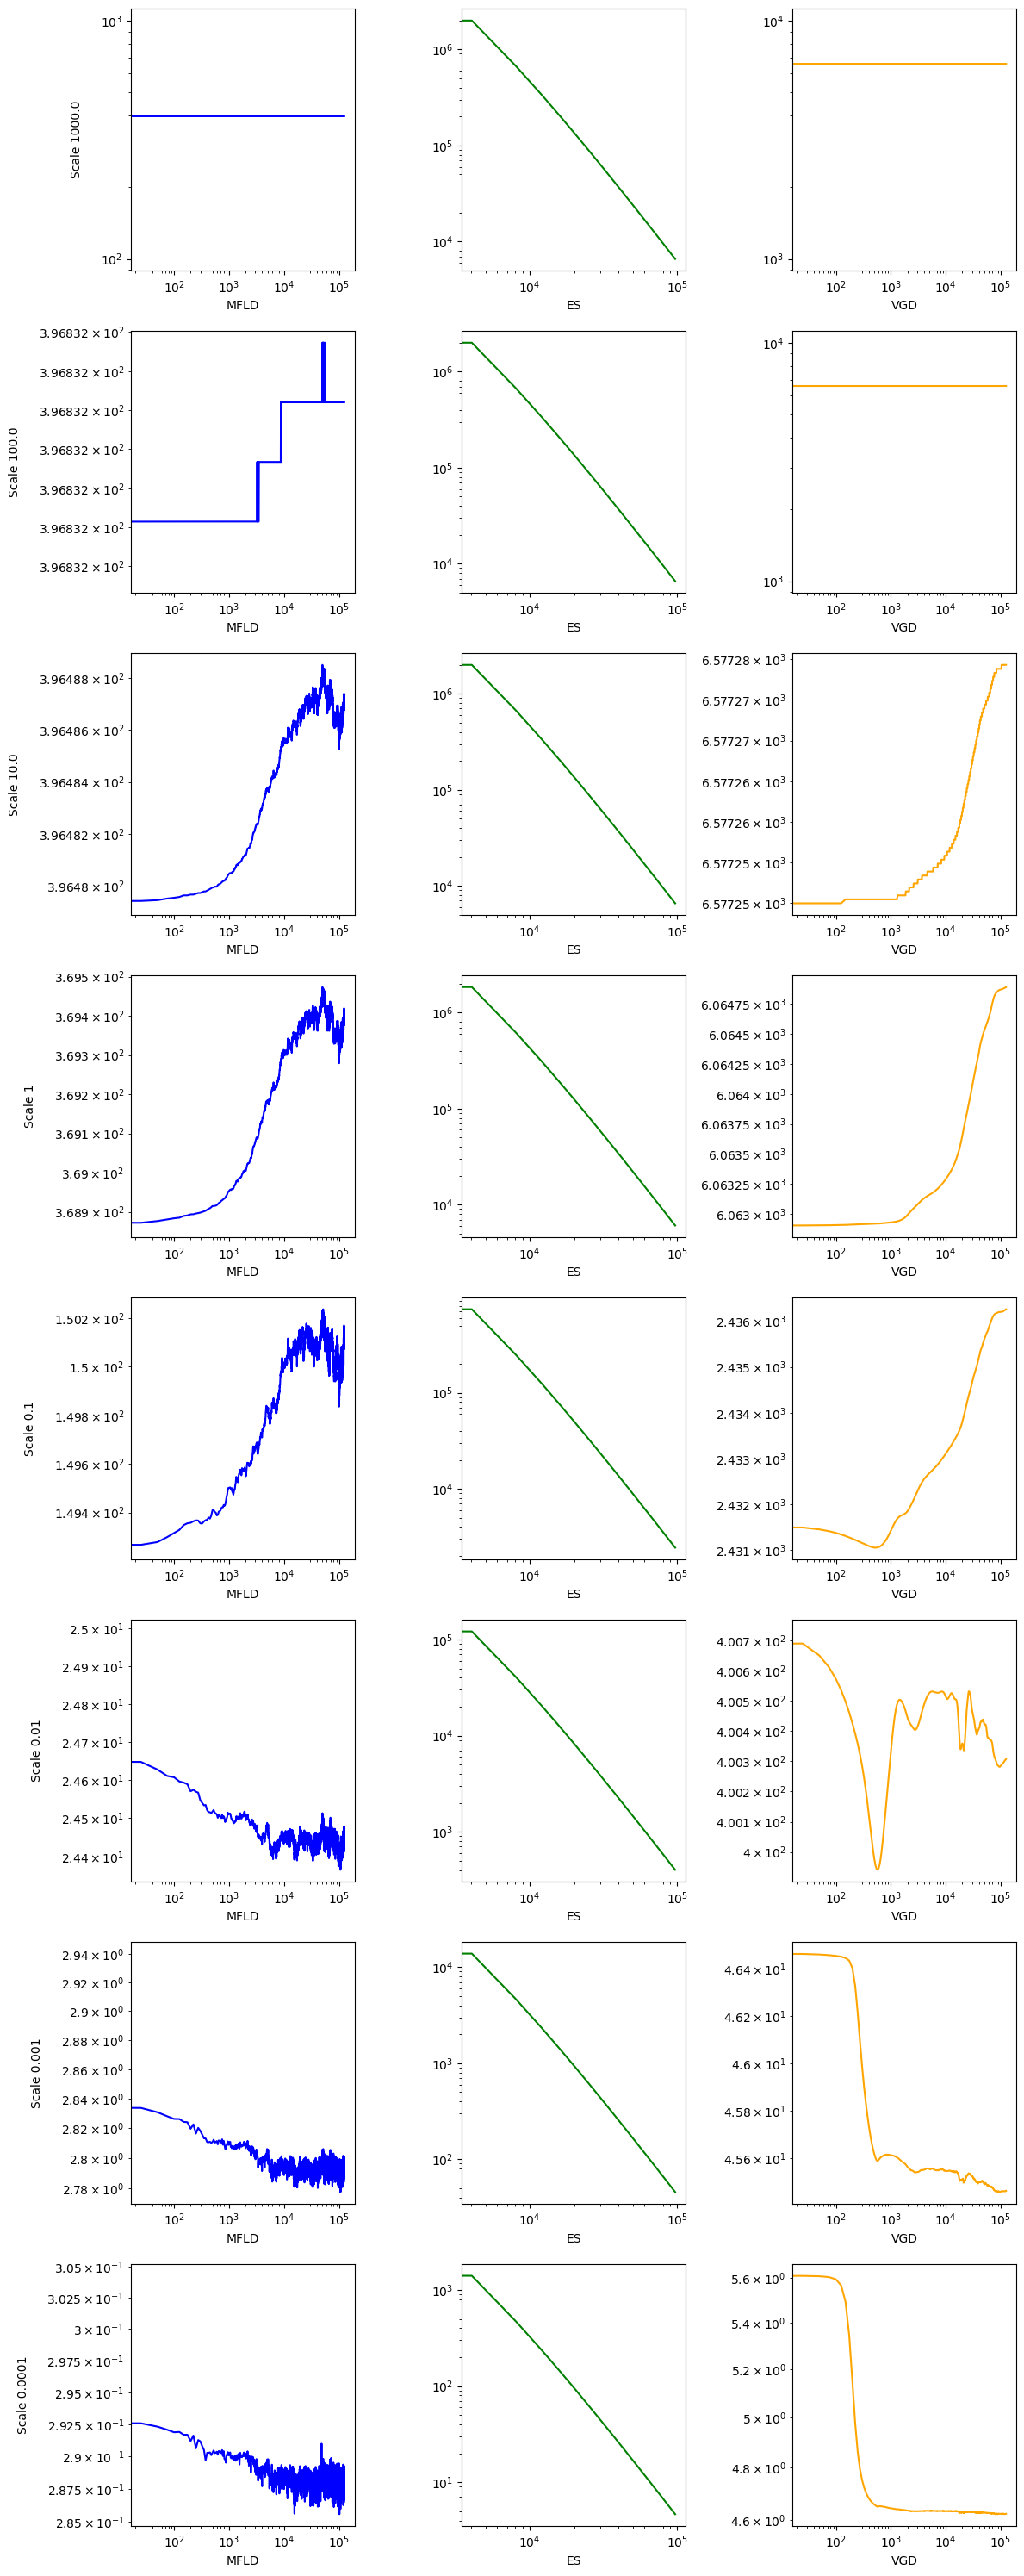

In [ ]:
fig, axes = plt.subplots(len(kgd_lengthscales_loaded["MFLD"]["Scales"]), 3, figsize=(12, 30))

for s, scales in enumerate(kgd_lengthscales_loaded["MFLD"]["Scales"]):
    i=s
    axes[i, 0].plot(evaluations_grad_L, kgd_lengthscales_loaded["MFLD"]["MMD_scales"][s], label='MFLD', color='blue')
    axes[i, 2].plot(evaluations_grad_L, kgd_lengthscales_loaded["Variational Gradient Descent"]["MMD_scales"][s], label='VGD', color='orange')
    axes[i, 1].plot(eval_gradL_ES, kgd_lengthscales_loaded["Extensible Sampling"]["MMD_scales"][s], label='ES', color='green')
    axes[i, 0].set_ylabel(f'Scale {scales}', fontsize=10, labelpad=15)  # Réduire la taille du titre
    axes[i, 0].set_xlabel('MFLD')
    axes[i, 1].set_xlabel('ES')
    axes[i, 2].set_xlabel('VGD')
    axes[i, 0].set_xscale('log')
    axes[i, 0].set_yscale('log')
    axes[i, 1].set_xscale('log')
    axes[i, 1].set_yscale('log')
    axes[i, 2].set_xscale('log')
    axes[i, 2].set_yscale('log')


plt.tight_layout()
plt.show()